NameError: name 'runs' is not defined

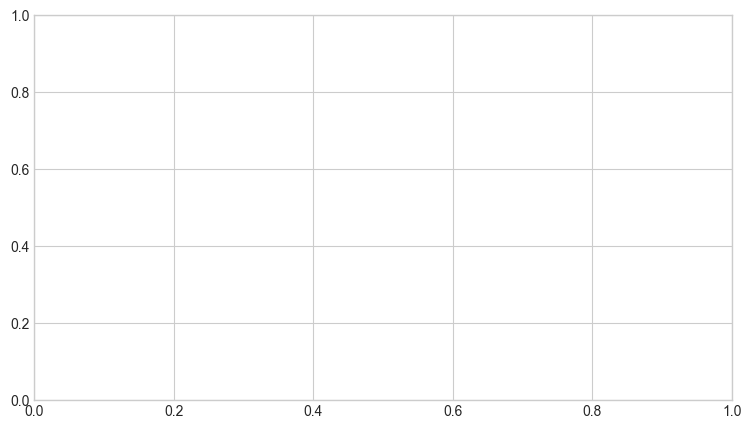

In [6]:
import matplotlib.pyplot as plt

# Global style tweaks
plt.style.use("seaborn-v0_8-whitegrid")

TITLE_SIZE = 16
LABEL_SIZE = 12


# ---------- Plot 1: Total runs contributed ----------
fig, ax = plt.subplots(figsize=(9,5))

bars = ax.bar(
    runs,
    runs_times_freq,
    color="#4C72B0",
    edgecolor="black",
    linewidth=0.7
)

ax.set_title("2025 MLB Runs Produced by Inning Run Count", fontsize=TITLE_SIZE, weight="bold")
ax.set_xlabel("Runs Scored in Inning", fontsize=LABEL_SIZE)
ax.set_ylabel("Total Runs from Innings", fontsize=LABEL_SIZE)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_xticks(runs)

# Value labels
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()



# ---------- Plot 2: Percent of innings ----------
fig, ax = plt.subplots(figsize=(9,5))

bars = ax.bar(
    runs_all,
    percentages,
    color="#DD8452",
    edgecolor="black",
    linewidth=0.7
)

ax.set_title("Percent of Innings by Runs Scored (2025 MLB)", fontsize=TITLE_SIZE, weight="bold")
ax.set_xlabel("Runs Scored in Inning", fontsize=LABEL_SIZE)
ax.set_ylabel("Percent of Innings", fontsize=LABEL_SIZE)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_xticks(runs_all)

# Value labels
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [ ]:
team_abv_dict = {
    'ANA' : 'Los Angeles Angels',
    'ARI' : 'Arizona Diamondbacks',
    'ATH' : 'Athletics',
    'ATL' : 'Atlanta Braves',
    'BAL' : 'Baltimore Orioles',
    'BOS' : 'Boston Red Sox',
    'CHA' : 'Chicago White Sox',
    'CHN' : 'Chicago Cubs',
    'CIN' : 'Cinncinati Reds',
    'CLE' : 'Cleveland Guardians',
    'COL' : 'Colorado Rockies',
    'DET' : 'Detroit Tigers',
    'HOU' : 'Houston Astros',
    'KCA' : 'Kansas City Royals',
    'LAN' : 'Los Angeles Dodgers',
    'MIA' : 'Miami Marlins',
    'MIL' : 'Milwaukee Brewers',
    'MIN' : 'Minnesota Twins',
    'NYA' : 'New York Yankees',
    'NYN' : 'New York Mets',
    'PHI' : 'Philadelphia Phillies',
    'PIT' : 'Pittsburgh Pirates',
    'SDN' : 'San Diego Padres',
    'SEA' : 'Seattle Mariners',
    'SFN' : 'San Francisco Giants',
    'SLN' : 'St. Louis Cardinals',
    'TBA' : 'Tampa Bay Rays',
    'TEX' : 'Texas Rangers',
    'TOR' : 'Toronto Blue Jays',
    'WAS' : 'Washington Nationals'
}



In [20]:
import csv
import json
import re
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import urllib.request
import numpy as np
import os

plt.style.use("seaborn-v0_8-whitegrid")

TITLE_SIZE = 16
LABEL_SIZE = 12


def parse_line_score(line):
    innings = re.findall(r'\(\d+\)|\d', line)

    runs = []
    for inn in innings:
        if inn.startswith("("):
            runs.append(int(inn.strip("()")))
        else:
            runs.append(int(inn))
    return runs


# -----------------------------
# Load team metadata
# -----------------------------
with open("All Teams Completed - No players.json") as f:
    league_data = json.load(f)

abrrev_fixes = {
    'ATH' : 'OAK',
    'CHA' : 'CWS',
    'CHN' : 'CCB',
    'KCA' : 'KC',
    'LAN' : 'LAD',
    'NYA' : 'NYY',
    'NYN' : 'NYM',
    'SDN' : 'SD',
    'SFN' : 'SFG',
    'SLN' : 'STL',
    'TBA' : 'TPA'
}

reverse_fixes = {v: k for k, v in abrrev_fixes.items()}

team_meta = {}

for t in league_data["teams"]:
    abbr = reverse_fixes.get(t["abbrev"], t["abbrev"])
    team_meta[abbr] = {
        "color": t["colors"][0],
        "logo": t["imgURL"]
    }

# -----------------------------
# Parse gamelog
# -----------------------------
mlb_counts = Counter()
mlb_run_contrib = Counter()

team_counts = defaultdict(Counter)
team_run_contrib = defaultdict(Counter)

with open("gl2025.txt", newline="") as f:
    reader = csv.reader(f)

    for row in reader:

        away = row[3]
        home = row[6]

        visitor_line = parse_line_score(row[19])[:9]
        home_line = parse_line_score(row[20])[:9]

        for r in visitor_line:
            mlb_counts[r] += 1
            mlb_run_contrib[r] += r

            team_counts[away][r] += 1
            team_run_contrib[away][r] += r

        for r in home_line:
            mlb_counts[r] += 1
            mlb_run_contrib[r] += r

            team_counts[home][r] += 1
            team_run_contrib[home][r] += r


# -----------------------------
# MLB baseline distributions
# -----------------------------
runs_all = sorted(mlb_counts.keys())

total_innings = sum(mlb_counts.values())
mlb_percent = [mlb_counts[r] / total_innings * 100 for r in runs_all]

total_runs = sum(mlb_run_contrib.values())
mlb_run_share = [mlb_run_contrib[r] / total_runs * 100 for r in runs_all]


# -----------------------------
# Utility: add team logo
# -----------------------------
def add_logo(ax, url):

    try:
        with urllib.request.urlopen(url) as url_obj:
            img = plt.imread(url_obj, format="gif")

        imagebox = OffsetImage(img, zoom=0.35)

        ab = AnnotationBbox(
            imagebox,
            (1, 1),
            frameon=False,
            xycoords='axes fraction',
            box_alignment=(1,1)
        )

        ax.add_artist(ab)
    except:
        pass


# -----------------------------
# Generate plots for each team
# -----------------------------
for team_abv, counts in team_counts.items():

    if team_abv not in team_meta:
        continue

    team_dir = f"team_imgs/{team_abv}"
    os.makedirs(team_dir, exist_ok=True)
    
    team_name = team_abv_dict[team_abv]
    team_color = team_meta[team_abv]["color"]
    team_logo = team_meta[team_abv]["logo"]

    team_total_innings = sum(counts.values())
    team_percent = [counts[r] / team_total_innings * 100 for r in runs_all]

    team_total_runs = sum(team_run_contrib[team_abv].values())
    team_run_share = [
        team_run_contrib[team_abv][r] / team_total_runs * 100
        if team_total_runs > 0 else 0
        for r in runs_all
    ]

    x = np.arange(len(runs_all))
    width = 0.35


    # -------------------------
    # Chart 1: Share of Runs
    # -------------------------
    fig, ax = plt.subplots(figsize=(9,5))

    ax.bar(
        x,
        mlb_run_share,
        width,
        color="#d3d3d3",
        label="MLB Average"
    )

    ax.bar(
        x + width/2,
        team_run_share,
        width,
        color=team_color,
        label=team_name
    )

    ax.set_title(f"{team_name}: Share of Runs by Inning Run Count (2025)", fontsize=TITLE_SIZE, weight="bold")

    ax.set_xlabel("Runs Scored in Inning", fontsize=LABEL_SIZE)
    ax.set_ylabel("Share of Runs (%)", fontsize=LABEL_SIZE)

    ax.set_xticks(x)
    ax.set_xticklabels(runs_all)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(
        loc="center right",
        frameon=False
    )

    add_logo(ax, team_logo)

    plt.tight_layout()

    plt.savefig(f"{team_dir}/runs_share.png", dpi=200)

    plt.close()


    # -------------------------
    # Chart 2: Percent innings
    # -------------------------
    fig, ax = plt.subplots(figsize=(9,5))

    ax.bar(
        x,
        mlb_percent,
        width,
        color="#d3d3d3",
        label="MLB Average"
    )

    ax.bar(
        x + width/2,
        team_percent,
        width,
        color=team_color,
        label=team_name
    )

    ax.set_title(f"{team_name}: Percent of Innings by Runs Scored (2025)", fontsize=TITLE_SIZE, weight="bold")

    ax.set_xlabel("Runs Scored in Inning", fontsize=LABEL_SIZE)
    ax.set_ylabel("Percent of Innings", fontsize=LABEL_SIZE)

    ax.set_xticks(x)
    ax.set_xticklabels(runs_all)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(
        loc="center right",
        frameon=False
    )

    add_logo(ax, team_logo)

    plt.tight_layout()

    plt.savefig(f"{team_dir}/inning_percent.png", dpi=200)

    plt.close()

In [17]:
for t in league_data["teams"]:
    abbr = abrrev_fixes.get(t["abbrev"], t["abbrev"])
    print(f"{abbr} : '{t['name']}',")

ATL : 'Braves',
BAL : 'Orioles',
NYM : 'Mets',
BOS : 'Red Sox',
CCB : 'Cubs',
CIN : 'Reds',
CLE : 'Guardians',
TEX : 'Rangers',
COL : 'Rockies',
DET : 'Tigers',
HOU : 'Astros',
CWS : 'White Sox',
KC : 'Royals',
LAA : 'Angels',
LAD : 'Dodgers',
MIA : 'Marlins',
MIL : 'Brewers',
MIN : 'Twins',
NYY : 'Yankees',
OAK : 'Athletics',
PHI : 'Phillies',
ARI : 'Diamondbacks',
PIT : 'Pirates',
SD : 'Padres',
SEA : 'Mariners',
SFG : 'Giants',
STL : 'Cardinals',
TOR : 'Blue Jays',
TPA : 'Rays',
WAS : 'Nationals',
